# Target relationships — approval rate by feature

How does the approval decision (`target`) vary across the protected attributes and core loan/financial
fields kept by `data_cleaning.ipynb`? This is the systematic feature-vs-target pass that notebook didn't
cover — its EDA was either univariate (distributions, missingness) or narrowly target-conditional just
for leakage detection, and the automated `ydata-profiling` report runs in `minimal=True` mode, which
explicitly disables correlations and pairwise/target interactions.

**Uses `data/processed/train.parquet` only** — not `val`/`test`. Any exploratory conclusion drawn here
should hold up independent of the data reserved for evaluation; looking at val/test now would mean
decisions made from this notebook have already "seen" the data the team evaluates models on later.

**Scope:** protected attributes (`derived_race`, `derived_ethnicity`, `derived_sex`, `applicant_age`,
`has_co_applicant`) + core loan/financial fields (`loan_type`, `loan_purpose`, `occupancy_type`,
`loan_amount`, `income`, `combined_loan_to_value_ratio`, `debt_to_income_ratio`, `property_value`) — the
ones most likely to matter for both prediction and fairness, not all 66 kept features. Extending to more
features means adding another call to the same two helper functions below.

**Color convention, used consistently throughout:** blue = denied (`target=0`), orange = originated
(`target=1`) — the same validated pair the rest of the project's palette uses for a 2-series
comparison.

In [1]:
from pathlib import Path
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt

TRAIN_PATH = Path("../data/processed/train.parquet")
train = pl.read_parquet(TRAIN_PATH)
print(f"{train.height:,} rows, {train.width} columns")

COLOR_DENIED = "#2a78d6"      # target = 0
COLOR_ORIGINATED = "#eb6834"  # target = 1
OVERALL_RATE = train["target"].mean()

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.5,
    "font.size": 10,
    "figure.dpi": 100,
})

6,393,228 rows, 67 columns


## Helper functions

One for categorical features (bar chart of approval rate per category, sample size annotated), one for
numeric features (density overlay split by outcome, means/medians printed below).

In [2]:
def approval_rate_by_category(df, col, order=None, labels=None, title=None):
    """Bar chart of approval rate per category, sorted by rate unless an explicit order is given."""
    g = df.group_by(col).agg(pl.len().alias("n"), pl.col("target").mean().alias("approval_rate"))
    pdf = g.to_pandas()
    if labels:
        pdf[col] = pdf[col].map(labels).fillna(pdf[col].astype(str))
    if order:
        cats = [labels.get(o, o) if labels else o for o in order]
        pdf[col] = pd.Categorical(pdf[col], categories=cats, ordered=True)
        pdf = pdf.sort_values(col)
    else:
        pdf = pdf.sort_values("approval_rate")

    fig, ax = plt.subplots(figsize=(7, max(2.2, 0.45 * len(pdf))))
    bars = ax.barh(pdf[col].astype(str), pdf["approval_rate"], color=COLOR_ORIGINATED, height=0.6)
    ax.axvline(OVERALL_RATE, color="0.4", linestyle="--", linewidth=1,
               label=f"overall rate ({OVERALL_RATE:.1%})")
    for bar, n in zip(bars, pdf["n"]):
        ax.text(bar.get_width() + 0.012, bar.get_y() + bar.get_height() / 2, f"n={n:,}",
                va="center", fontsize=8, color="0.35")
    ax.set_xlabel("Approval rate (target = 1)")
    ax.set_xlim(0, 1.12)
    ax.set_title(title or f"Approval rate by {col}")
    ax.legend(loc="lower right", frameon=False)
    plt.tight_layout()
    plt.show()
    return pdf[[col, "n", "approval_rate"]].reset_index(drop=True)


def distribution_by_target(df, col, bins=40, clip=None, log=False):
    """Overlaid density histogram split by target, means/medians printed below."""
    sub = df.select([col, "target"]).drop_nulls()
    pdf = sub.to_pandas()
    rng = clip if clip else (pdf[col].min(), pdf[col].max())

    fig, ax = plt.subplots(figsize=(7, 4))
    for t, color, label in [(0, COLOR_DENIED, "Denied"), (1, COLOR_ORIGINATED, "Originated")]:
        vals = pdf.loc[pdf["target"] == t, col]
        ax.hist(vals, bins=bins, range=rng, density=True, alpha=0.55, color=color,
                label=f"{label} (n={len(vals):,})")
    ax.set_xlabel(col + (" (clipped to 1st-99th pctile for display)" if clip else ""))
    ax.set_ylabel("Density")
    ax.set_title(f"{col} distribution by outcome")
    if log:
        ax.set_xscale("log")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    stats = sub.group_by("target").agg(
        pl.col(col).mean().round(1).alias("mean"),
        pl.col(col).median().round(1).alias("median"),
    ).sort("target")
    print(stats)

## Protected attributes

### `derived_race`

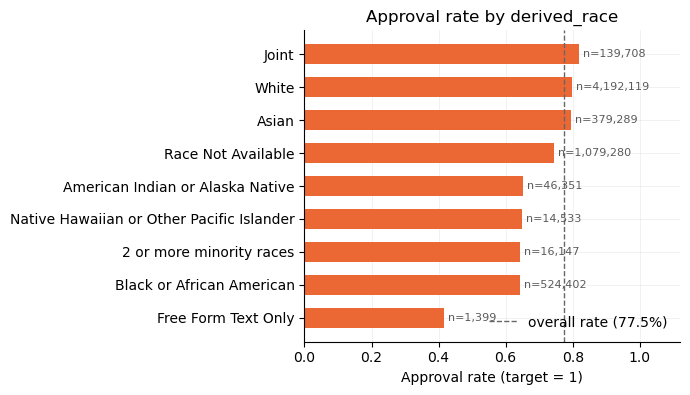

In [3]:
_ = approval_rate_by_category(train, "derived_race")

### `derived_ethnicity`

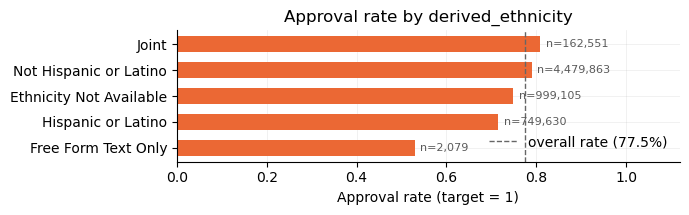

In [4]:
_ = approval_rate_by_category(train, "derived_ethnicity")

### `derived_sex`

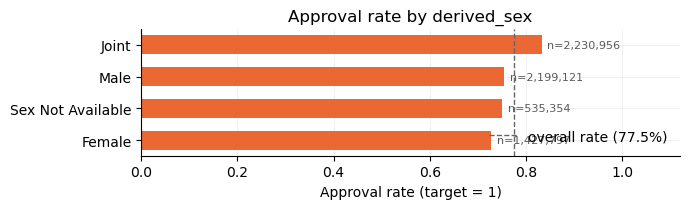

In [5]:
_ = approval_rate_by_category(train, "derived_sex")

### `applicant_age`

Ordered by age band rather than by rate, since the bands have a natural order.

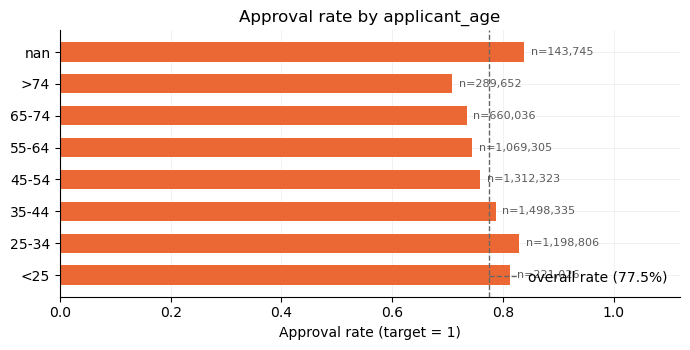

In [6]:
AGE_ORDER = ["<25", "25-34", "35-44", "45-54", "55-64", "65-74", ">74"]
_ = approval_rate_by_category(train, "applicant_age", order=AGE_ORDER)

### `has_co_applicant`

Derived in `data_cleaning.ipynb` §4e from `co_applicant_age`'s sentinel value.

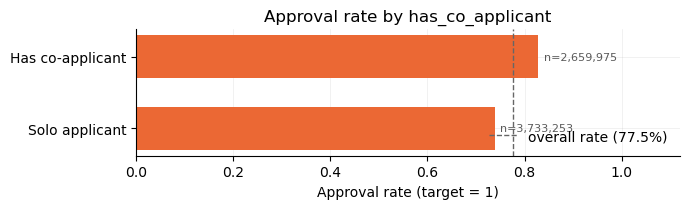

In [7]:
_ = approval_rate_by_category(
    train, "has_co_applicant",
    labels={True: "Has co-applicant", False: "Solo applicant"},
)

## Core loan / financial fields

### `loan_type`

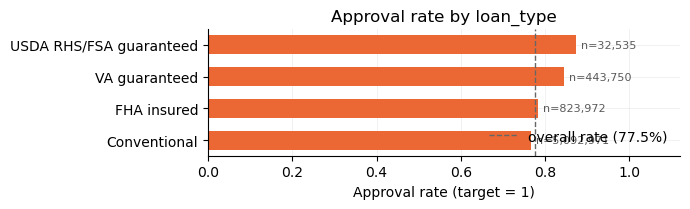

In [8]:
LOAN_TYPE_LABELS = {1: "Conventional", 2: "FHA insured", 3: "VA guaranteed", 4: "USDA RHS/FSA guaranteed"}
_ = approval_rate_by_category(train, "loan_type", labels=LOAN_TYPE_LABELS)

### `loan_purpose`

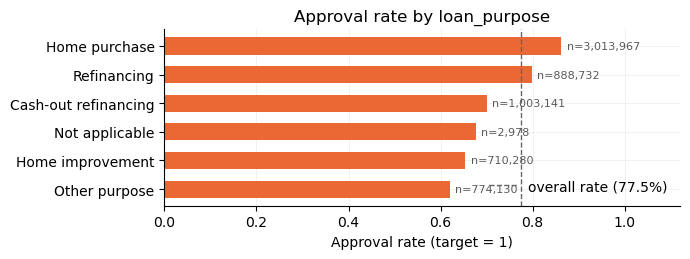

In [9]:
LOAN_PURPOSE_LABELS = {
    1: "Home purchase", 2: "Home improvement", 31: "Refinancing",
    32: "Cash-out refinancing", 4: "Other purpose", 5: "Not applicable",
}
_ = approval_rate_by_category(train, "loan_purpose", labels=LOAN_PURPOSE_LABELS)

### `occupancy_type`

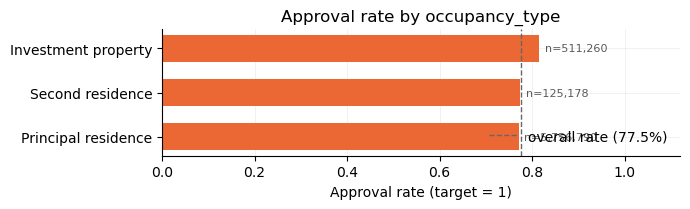

In [10]:
OCCUPANCY_TYPE_LABELS = {1: "Principal residence", 2: "Second residence", 3: "Investment property"}
_ = approval_rate_by_category(train, "occupancy_type", labels=OCCUPANCY_TYPE_LABELS)

### `loan_amount`

Heavy right tail (privacy-preserving reporting allows very large values) — display clipped to the
1st-99th percentile ($15,000-$1,565,000); the underlying data isn't altered, only the chart range.

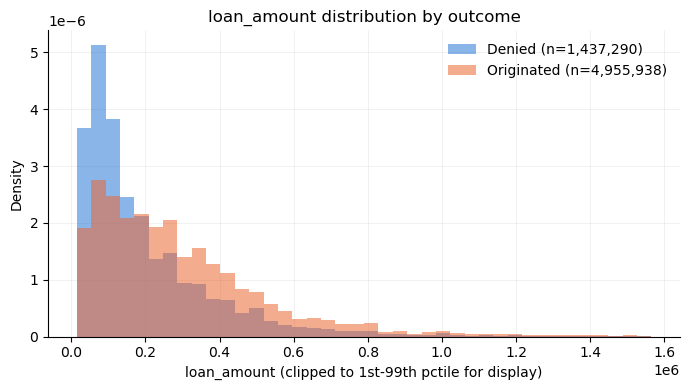

shape: (2, 3)
┌────────┬──────────┬──────────┐
│ target ┆ mean     ┆ median   │
│ ---    ┆ ---      ┆ ---      │
│ i8     ┆ f64      ┆ f64      │
╞════════╪══════════╪══════════╡
│ 0      ┆ 220295.0 ┆ 135000.0 │
│ 1      ┆ 343887.2 ┆ 245000.0 │
└────────┴──────────┴──────────┘


In [11]:
distribution_by_target(train, "loan_amount", clip=(15_000, 1_565_000))

### `income`

Reported in thousands of dollars. Same heavy-tail clipping as `loan_amount`.

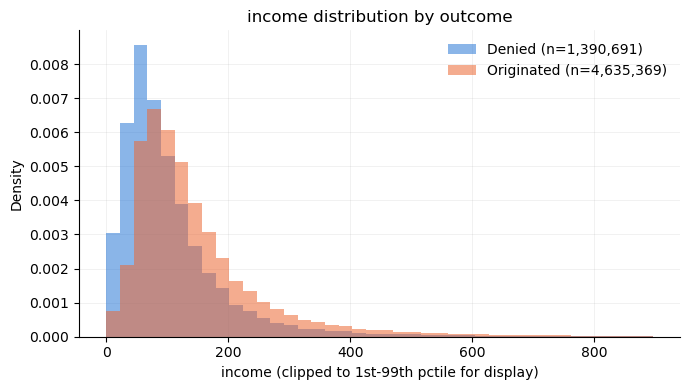

shape: (2, 3)
┌────────┬───────┬────────┐
│ target ┆ mean  ┆ median │
│ ---    ┆ ---   ┆ ---    │
│ i8     ┆ f64   ┆ f64    │
╞════════╪═══════╪════════╡
│ 0      ┆ 216.0 ┆ 81.0   │
│ 1      ┆ 191.2 ┆ 116.0  │
└────────┴───────┴────────┘


In [12]:
distribution_by_target(train, "income", clip=(0, 896))

### `combined_loan_to_value_ratio`

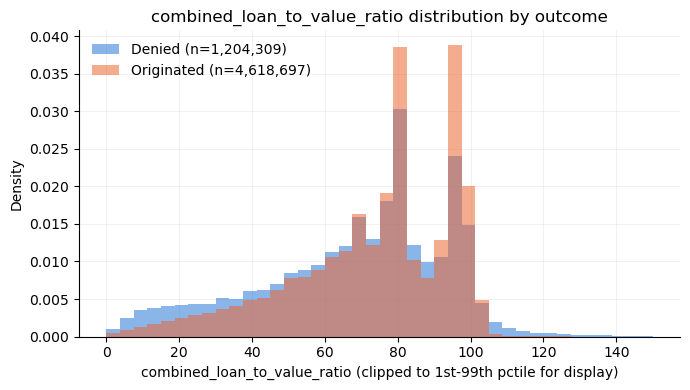

shape: (2, 3)
┌────────┬────────┬────────┐
│ target ┆ mean   ┆ median │
│ ---    ┆ ---    ┆ ---    │
│ i8     ┆ f64    ┆ f64    │
╞════════╪════════╪════════╡
│ 0      ┆ 1780.1 ┆ 74.5   │
│ 1      ┆ 139.5  ┆ 78.8   │
└────────┴────────┴────────┘


In [13]:
distribution_by_target(train, "combined_loan_to_value_ratio", clip=(0, 150))

### `debt_to_income_ratio`

Recall from `data_cleaning.ipynb` §4e: values above 60% and below 20% are bucket-midpoint estimates
(70 and 10 respectively), not exact reported numbers — the spike at 70 reflects that, not a real
concentration of applicants exactly at 70%.

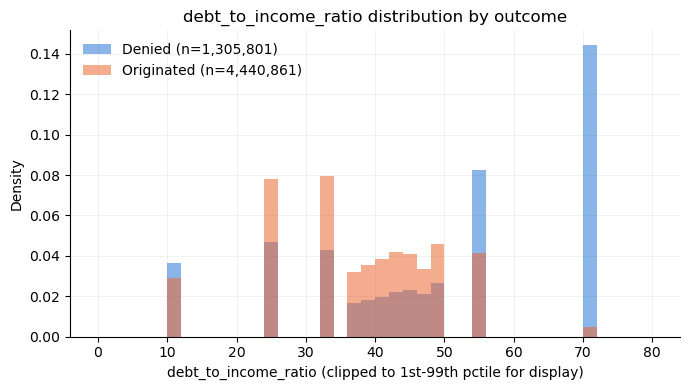

shape: (2, 3)
┌────────┬──────┬────────┐
│ target ┆ mean ┆ median │
│ ---    ┆ ---  ┆ ---    │
│ i8     ┆ f64  ┆ f64    │
╞════════╪══════╪════════╡
│ 0      ┆ 47.9 ┆ 48.0   │
│ 1      ┆ 37.8 ┆ 39.0   │
└────────┴──────┴────────┘


In [14]:
distribution_by_target(train, "debt_to_income_ratio", clip=(0, 80))

### `property_value`

Same heavy-tail clipping rationale as `loan_amount`.

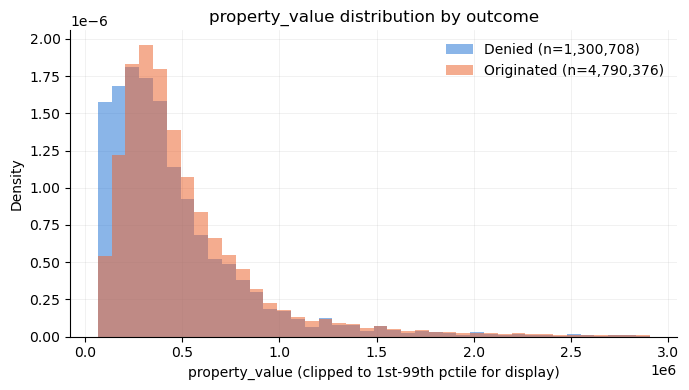

shape: (2, 3)
┌────────┬──────────┬──────────┐
│ target ┆ mean     ┆ median   │
│ ---    ┆ ---      ┆ ---      │
│ i8     ┆ f64      ┆ f64      │
╞════════╪══════════╪══════════╡
│ 0      ┆ 525835.4 ┆ 355000.0 │
│ 1      ┆ 606206.9 ┆ 405000.0 │
└────────┴──────────┴──────────┘


In [15]:
distribution_by_target(train, "property_value", clip=(65_000, 2_905_000))

## Extending this notebook

To add another feature: call `approval_rate_by_category(train, "column_name")` for a categorical field
(pass `labels={...}` to map codes to readable names, `order=[...]` if it has a natural order), or
`distribution_by_target(train, "column_name")` for a numeric one (pass `clip=(low, high)` if it has a
heavy tail). Both helpers are defined once, near the top of this notebook.